Shape of dataset: (569, 30)
Number of features: 30
Target classes: ['malignant' 'benign']

Shape after PCA: (569, 2)
        PC1        PC2  Target
0  9.192837   1.948583       0
1  2.387802  -3.768172       0
2  5.733896  -1.075174       0
3  7.122953  10.275589       0
4  3.935302  -1.948072       0


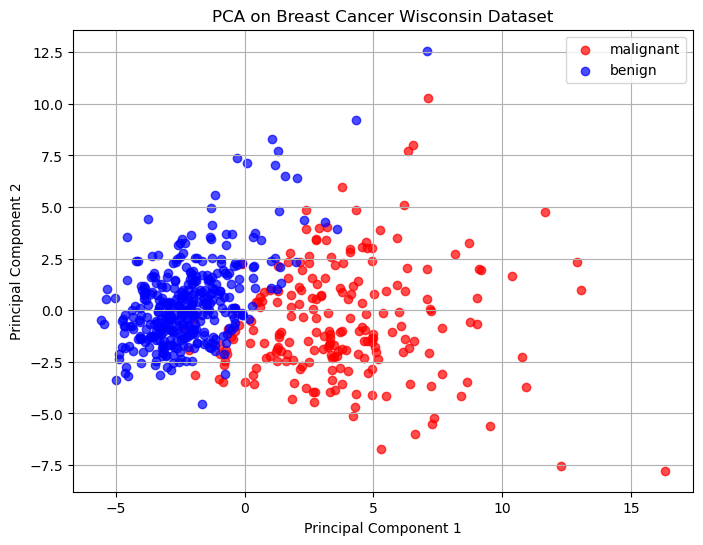

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load the dataset
cancer = load_breast_cancer()

# Features and target
X = cancer.data
y = cancer.target

# Display dataset information
print("Shape of dataset:", X.shape)
print("Number of features:", X.shape[1])
print("Target classes:", cancer.target_names)

# Step 1: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Compute covariance matrix
cov_matrix = np.cov(X_scaled.T)

# Step 3: Compute eigenvalues and eigenvectors
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# Step 4: Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

# Step 5: Choose number of principal components
k = 2

# Step 6: Create projection matrix
projection_matrix = eigen_vectors[:, :k]

# Step 7: Transform data into principal component space
X_pca = X_scaled.dot(projection_matrix)

# Display transformed data
print("\nShape after PCA:", X_pca.shape)

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Target"] = y

print(pca_df.head())

# Step 8: Visualize PCA result
plt.figure(figsize=(8,6))

for label, color in zip([0,1], ['red','blue']):
    plt.scatter(
        pca_df[pca_df["Target"] == label]["PC1"],
        pca_df[pca_df["Target"] == label]["PC2"],
        c=color,
        label=cancer.target_names[label],
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Breast Cancer Wisconsin Dataset")
plt.legend()
plt.grid(True)
plt.show()

Shape of dataset: (178, 13)
Number of features: 13
Number of samples: 178

Explained Variance Ratio:
[0.36198848 0.1920749 ]

Total Explained Variance:
0.5540633835693529


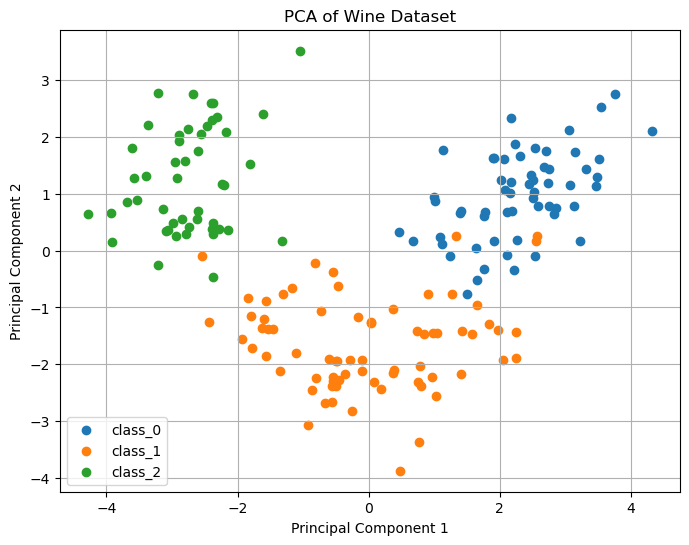

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Wine dataset
wine = load_wine()

# Features and target
X = wine.data
y = wine.target

# Feature names
feature_names = wine.feature_names

# Display dataset information
print("Shape of dataset:", X.shape)
print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Display explained variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(np.sum(pca.explained_variance_ratio_))

# Plot the PCA result
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=wine.target_names[label]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Wine Dataset")
plt.legend()
plt.grid(True)
plt.show()